In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

# ==========================================
# 1. 设定真实参数 (上帝视角)
# ==========================================
TRUE_W0 = -0.3  # 真实截距
TRUE_W1 = 0.5   # 真实斜率

# ==========================================
# 2. 生成观测数据
# ==========================================
np.random.seed(42)
def generate_data(n_samples, noise_std):
    x = np.random.uniform(-1, 1, n_samples)
    # 真实模型 y = w0 + w1*x + 噪声
    y = TRUE_W0 + TRUE_W1 * x + np.random.normal(0, noise_std, n_samples)
    return x, y

# ==========================================
# 3. 贝叶斯更新核心函数 (网格法)
# 我们在 w0 和 w1 的二维空间中铺设网格，计算每个点的概率密度
# 这就是所谓的 "全联合概率密度分布"
# ==========================================
def compute_likelihood(x, y, w0_grid, w1_grid, noise_std):
    """计算单个数据点带来的似然分布 (Likelihood)"""
    # 预测值 y_pred = w0 + w1*x
    y_pred = w0_grid + w1_grid * x
    # 似然是高斯分布：给定 w0, w1 时，真实 y 出现的概率
    likelihood = norm.pdf(y, loc=y_pred, scale=noise_std)
    return likelihood

def plot_bayesian_update(noise_std=0.2, prior_std=0.5, data_points=[1, 2, 20]):
    """
    可视化贝叶斯更新过程
    noise_std: 数据的噪声标准差 (你可以手动修改体会变化)
    prior_std: 先验分布的标准差 (表示我们初始时的无知程度)
    """
    # 生成 20 个数据点
    X_data, Y_data = generate_data(max(data_points), noise_std)
    
    # 创建 w0, w1 的二维网格 (参数空间)
    grid_size = 100
    w0_range = np.linspace(-1, 1, grid_size)
    w1_range = np.linspace(-1, 1, grid_size)
    W0, W1 = np.meshgrid(w0_range, w1_range)
    
    # 初始化先验分布 (Prior): 假设 w0, w1 独立且服从均值为0的高斯分布
    prior = multivariate_normal.pdf(
        np.dstack((W0, W1)), 
        mean=[0, 0], 
        cov=[[prior_std**2, 0], [0, prior_std**2]]
    )
    
    fig, axes = plt.subplots(len(data_points) + 1, 3, figsize=(15, 4 * (len(data_points) + 1)))
    plt.subplots_adjust(hspace=0.4)
    
    # --- 第 0 行：没有数据时的先验状态 ---
    axes[0, 0].text(0.5, 0.5, 'No Data\n(No Likelihood)', ha='center', va='center', fontsize=14)
    axes[0, 0].axis('off')
    
    axes[0, 1].contourf(W0, W1, prior, 100, cmap='jet')
    axes[0, 1].plot(TRUE_W0, TRUE_W1, 'w+', markersize=15, markeredgewidth=3) # 标记真实值
    axes[0, 1].set_title("Prior / Posterior Distribution\n(Joint Probability of w0, w1)")
    axes[0, 1].set_xlabel("Intercept (w0)")
    axes[0, 1].set_ylabel("Slope (w1)")
    
    # 在数据空间中，从先验分布中随机抽样几组 (w0, w1) 画线
    axes[0, 2].set_title("Data Space (Sampled Lines)")
    for _ in range(6):
        w_sample = multivariate_normal.rvs(mean=[0, 0], cov=[[prior_std**2, 0], [0, prior_std**2]])
        axes[0, 2].plot([-1, 1], [w_sample[0] - w_sample[1], w_sample[0] + w_sample[1]], 'r-', alpha=0.3)
    axes[0, 2].set_xlim(-1, 1); axes[0, 2].set_ylim(-1, 1)
    
    # --- 逐个加入数据点 ---
    current_posterior = prior
    
    for i, n_points in enumerate(data_points):
        row = i + 1
        
        # 取出最新的那个数据点计算似然
        x_n, y_n = X_data[n_points-1], Y_data[n_points-1]
        likelihood = compute_likelihood(x_n, y_n, W0, W1, noise_std)
        
        # 贝叶斯核心公式：后验 = 似然 * 先验 (这里用上一步的后验作为现在的先验)
        current_posterior = current_posterior * likelihood
        
        # 1. 画似然函数 (Likelihood)
        axes[row, 0].contourf(W0, W1, likelihood, 100, cmap='jet')
        axes[row, 0].plot(TRUE_W0, TRUE_W1, 'w+', markersize=15, markeredgewidth=3)
        axes[row, 0].set_title(f"Likelihood of Data Point {n_points}")
        
        # 2. 画更新后的后验分布 (Posterior)
        axes[row, 1].contourf(W0, W1, current_posterior, 100, cmap='jet')
        axes[row, 1].plot(TRUE_W0, TRUE_W1, 'w+', markersize=15, markeredgewidth=3)
        
        # 【频率学派的点估计对比】
        # 频率学派（MLE/OLS）会直接找目前所有数据的最佳拟合点
        if n_points >= 2: # 至少两点才能做简单的线性回归
            w1_mle, w0_mle = np.polyfit(X_data[:n_points], Y_data[:n_points], 1)
            axes[row, 1].plot(w0_mle, w1_mle, 'ko', markersize=8, label="Frequentist MLE")
            axes[row, 1].legend(loc='upper right')
            
        axes[row, 1].set_title(f"Posterior after {n_points} points")
        
        # 3. 画数据空间 (Data Space)
        axes[row, 2].scatter(X_data[:n_points], Y_data[:n_points], s=50, facecolors='none', edgecolors='blue')
        # 简单粗暴地从网格概率中抽样来画线 (模拟从后验抽样)
        flat_posterior = current_posterior.flatten()
        flat_posterior /= flat_posterior.sum() # 归一化
        sampled_indices = np.random.choice(len(flat_posterior), size=6, p=flat_posterior)
        for idx in sampled_indices:
            w0_s = W0.flatten()[idx]
            w1_s = W1.flatten()[idx]
            axes[row, 2].plot([-1, 1], [w0_s - w1_s, w0_s + w1_s], 'r-', alpha=0.3)
        axes[row, 2].set_xlim(-1, 1); axes[row, 2].set_ylim(-1, 1)
        axes[row, 2].set_title("Data Space (Sampled Lines)")

    plt.tight_layout()
    plt.show()

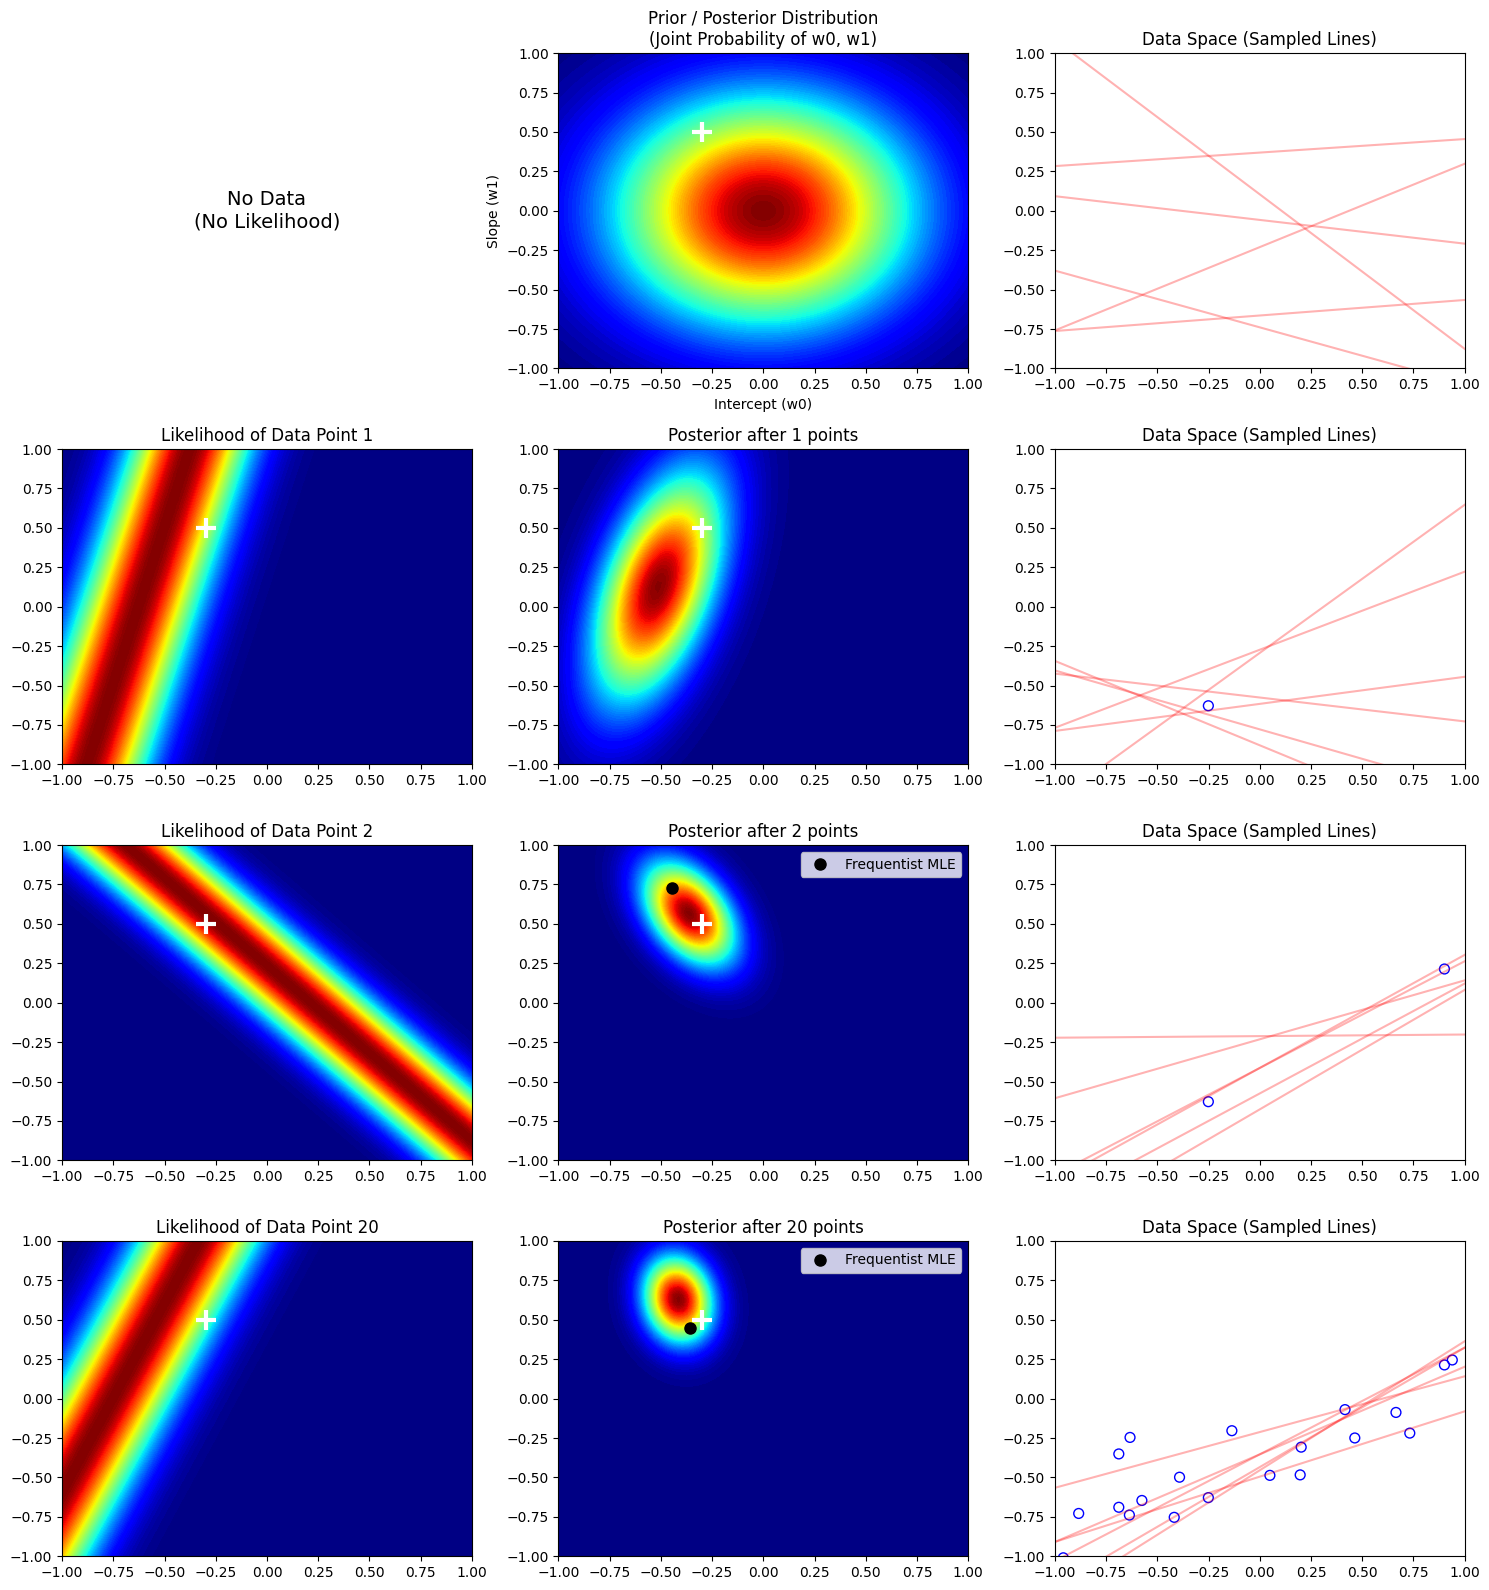

In [2]:
# 你可以尝试修改这里的参数：
# noise_std: 观测数据的噪声大小 (例如改成 0.5 看分布有多散，改成 0.05 看收敛有多快)
# prior_std: 初始信念的方差 (例如改成 0.1 表示一开始就非常笃定，改成 1.0 表示一开始很茫然)
plot_bayesian_update(noise_std=0.2, prior_std=0.5, data_points=[1, 2, 20])

## Generative Model

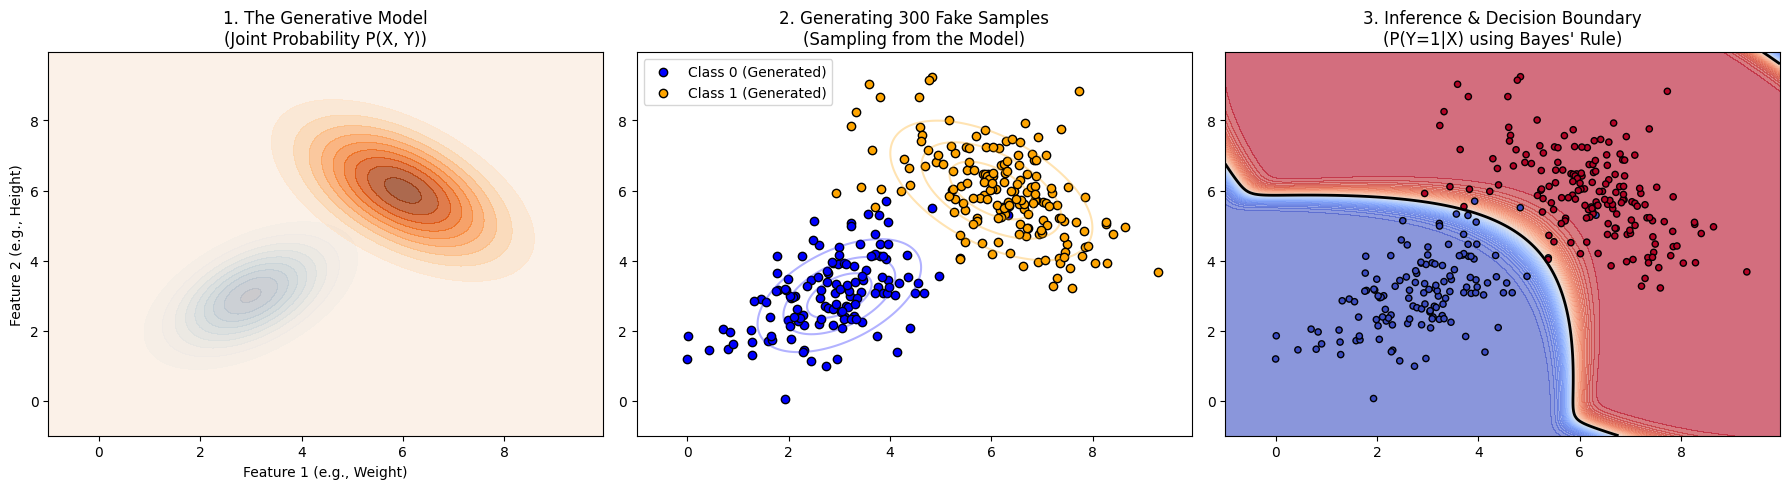

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# ==========================================
# 1. 定义“上帝造物”的规则 (生成模型的参数)
# ==========================================
# 假设我们要区分两个类别：类别 0 (比如猫) 和 类别 1 (比如狗)

# 规则 A: 先验概率 P(Y) - 世界上猫和狗的比例
PRIOR_0 = 0.4  # 40% 是猫
PRIOR_1 = 0.6  # 60% 是狗

# 规则 B: 似然 P(X|Y) - 给定类别，它们的特征(如体重x1, 身高x2)服从什么分布？
# 类别 0 (猫) 的高斯分布参数
MEAN_0 = np.array([3.0, 3.0])
COV_0 = np.array([[1.0, 0.5], 
                  [0.5, 1.0]]) # 协方差矩阵，决定了分布的形状和倾斜度

# 类别 1 (狗) 的高斯分布参数
MEAN_1 = np.array([6.0, 6.0])
COV_1 = np.array([[1.5, -0.8], 
                  [-0.8, 1.5]])

# ==========================================
# 2. 核心：数据的生成过程 (Generative Process)
# ==========================================
def generate_fake_data(n_samples):
    """按照上帝规则，凭空生成数据"""
    X_generated = []
    Y_generated = []
    
    for _ in range(n_samples):
        # 步骤 1: 掷骰子决定类别 (根据 P(Y))
        if np.random.rand() < PRIOR_0:
            y = 0
            # 步骤 2: 从该类别的专属分布中抽取特征 (根据 P(X|Y=0))
            x = np.random.multivariate_normal(MEAN_0, COV_0)
        else:
            y = 1
            # 步骤 2: 从该类别的专属分布中抽取特征 (根据 P(X|Y=1))
            x = np.random.multivariate_normal(MEAN_1, COV_1)
            
        X_generated.append(x)
        Y_generated.append(y)
        
    return np.array(X_generated), np.array(Y_generated)

# ==========================================
# 3. 可视化：生成模型的内涵
# ==========================================
def plot_generative_model(n_samples=300):
    # 生成网格，用于画概率密度等高线
    x1, x2 = np.mgrid[-1:10:.05, -1:10:.05]
    pos = np.dstack((x1, x2))
    
    # 计算两个类别的概率密度分布 P(X|Y)
    pdf_0 = multivariate_normal(MEAN_0, COV_0).pdf(pos)
    pdf_1 = multivariate_normal(MEAN_1, COV_1).pdf(pos)
    
    # 计算联合概率分布 P(X, Y) = P(X|Y) * P(Y)
    # 这就是生成模型眼中的“两座山”
    joint_0 = pdf_0 * PRIOR_0
    joint_1 = pdf_1 * PRIOR_1
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- 图 1：生成模型眼中的世界 (联合概率分布) ---
    axes[0].contourf(x1, x2, joint_0, levels=10, cmap='Blues', alpha=0.7)
    axes[0].contourf(x1, x2, joint_1, levels=10, cmap='Oranges', alpha=0.7)
    axes[0].set_title("1. The Generative Model\n(Joint Probability P(X, Y))")
    axes[0].set_xlabel("Feature 1 (e.g., Weight)"); axes[0].set_ylabel("Feature 2 (e.g., Height)")
    
    # --- 图 2：模型“凭空想象”生成的数据 ---
    X_fake, Y_fake = generate_fake_data(n_samples)
    axes[1].scatter(X_fake[Y_fake==0][:, 0], X_fake[Y_fake==0][:, 1], c='blue', edgecolors='k', label='Class 0 (Generated)')
    axes[1].scatter(X_fake[Y_fake==1][:, 0], X_fake[Y_fake==1][:, 1], c='orange', edgecolors='k', label='Class 1 (Generated)')
    # 把等高线作为背景淡淡地画上去
    axes[1].contour(x1, x2, joint_0, levels=3, colors='blue', alpha=0.3)
    axes[1].contour(x1, x2, joint_1, levels=3, colors='orange', alpha=0.3)
    axes[1].set_title(f"2. Generating {n_samples} Fake Samples\n(Sampling from the Model)")
    axes[1].legend()
    
    # --- 图 3：顺便做个分类 (贝叶斯定理) ---
    # 既然有了 P(X, Y)，我们就可以算出 P(Y|X) 来做分类
    # P(Y=1|X) = P(X, Y=1) / (P(X, Y=0) + P(X, Y=1))
    prob_class_1 = joint_1 / (joint_0 + joint_1 + 1e-10) # 加上 1e-10 防止除以 0
    
    # 画出决策边界 (P(Y=1|X) = 0.5 的地方)
    axes[2].contourf(x1, x2, prob_class_1, levels=50, cmap='coolwarm', alpha=0.6)
    axes[2].contour(x1, x2, prob_class_1, levels=[0.5], colors='black', linewidths=2) # 决策边界
    axes[2].scatter(X_fake[:, 0], X_fake[:, 1], c=Y_fake, cmap='coolwarm', edgecolors='k', s=20)
    axes[2].set_title("3. Inference & Decision Boundary\n(P(Y=1|X) using Bayes' Rule)")
    
    plt.tight_layout()
    plt.show()

# 运行可视化
np.random.seed(42)
plot_generative_model(n_samples=300)

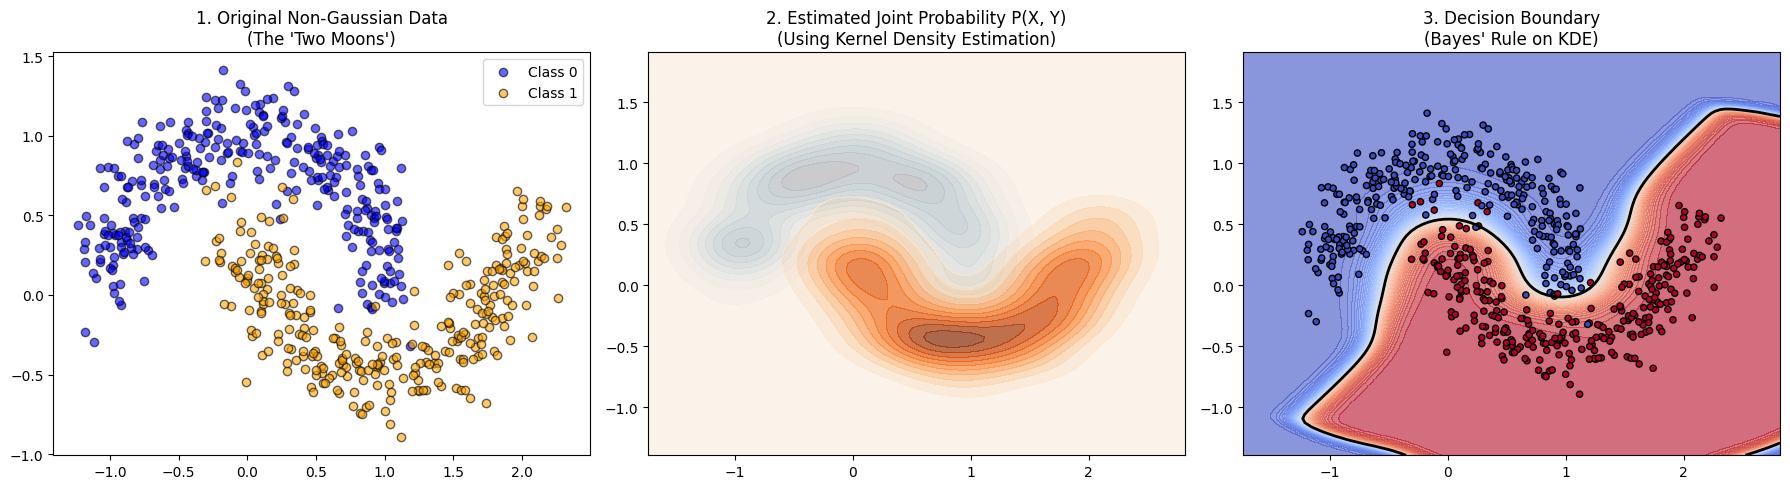

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from scipy.stats import gaussian_kde

# ==========================================
# 1. 获取非高斯分布的真实数据
# ==========================================
# 我们使用 sklearn 生成经典的 "双月" 数据集，它绝对不是标准的高斯分布
X, Y = make_moons(n_samples=600, noise=0.15, random_state=42)

# 分离两个类别的数据
X_0 = X[Y == 0]
X_1 = X[Y == 1]

# ==========================================
# 2. 从数据中“估计”生成模型 (非参数估计)
# ==========================================
# 估计先验概率 P(Y)
prior_0 = len(X_0) / len(X)
prior_1 = len(X_1) / len(X)

# 估计似然 P(X|Y) -> 使用核密度估计 (KDE)
# KDE 会在每个数据点上放一个小高斯包，然后把它们全加起来，从而拟合任意形状
kde_0 = gaussian_kde(X_0.T) # 注意 scipy 的 kde 要求特征在行上，所以要转置
kde_1 = gaussian_kde(X_1.T)

# ==========================================
# 3. 计算联合分布并可视化
# ==========================================
# 生成网格
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.mgrid[x1_min:x1_max:100j, x2_min:x2_max:100j]
positions = np.vstack([xx1.ravel(), xx2.ravel()])

# 计算 P(X|Y)
pdf_0 = kde_0(positions).reshape(xx1.shape)
pdf_1 = kde_1(positions).reshape(xx1.shape)

# 计算联合分布 P(X, Y) = P(X|Y) * P(Y)
joint_0 = pdf_0 * prior_0
joint_1 = pdf_1 * prior_1

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 图 1：原始的非高斯数据 ---
axes[0].scatter(X_0[:, 0], X_0[:, 1], c='blue', alpha=0.6, edgecolors='k', label='Class 0')
axes[0].scatter(X_1[:, 0], X_1[:, 1], c='orange', alpha=0.6, edgecolors='k', label='Class 1')
axes[0].set_title("1. Original Non-Gaussian Data\n(The 'Two Moons')")
axes[0].legend()

# --- 图 2：KDE 估计出的联合分布 P(X, Y) ---
# 你会看到山峰不再是椭圆，而是顺着数据弯曲的形状！
axes[1].contourf(xx1, xx2, joint_0, levels=10, cmap='Blues', alpha=0.7)
axes[1].contourf(xx1, xx2, joint_1, levels=10, cmap='Oranges', alpha=0.7)
axes[1].set_title("2. Estimated Joint Probability P(X, Y)\n(Using Kernel Density Estimation)")

# --- 图 3：基于估计出的分布进行分类 ---
# P(Y=1|X) = P(X, Y=1) / (P(X, Y=0) + P(X, Y=1))
prob_class_1 = joint_1 / (joint_0 + joint_1 + 1e-10)

axes[2].contourf(xx1, xx2, prob_class_1, levels=50, cmap='coolwarm', alpha=0.6)
axes[2].contour(xx1, xx2, prob_class_1, levels=[0.5], colors='black', linewidths=2) # 决策边界
axes[2].scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', edgecolors='k', s=20)
axes[2].set_title("3. Decision Boundary\n(Bayes' Rule on KDE)")

plt.tight_layout()
plt.show()

## Beta Distribution & Conjugate Prior（共轭先验）

**核心问题**：我们要估计一个未知的概率 $\theta$（比如一枚硬币正面朝上的概率，范围 $[0,1]$）。

**Beta 分布** 是定义在 $[0,1]$ 上的分布，天生适合用来描述“对一个概率的信念”：
$$\text{Beta}(\theta \mid \alpha, \beta) \propto \theta^{\alpha-1}(1-\theta)^{\beta-1}$$

直觉：可以把 $\alpha-1$ 看成“见过的正面次数”，$\beta-1$ 看成“见过的反面次数”。

**共轭先验 (Conjugate Prior)** 的魔法：
- 先验 (Prior): $\theta \sim \text{Beta}(\alpha, \beta)$
- 似然 (Likelihood): 观测到 $h$ 次正面、$t$ 次反面（二项/伯努利分布）
- 后验 (Posterior): $\theta \mid \text{data} \sim \text{Beta}(\alpha + h,\ \beta + t)$

后验还是 Beta 分布！所以更新只需做加法。这就是“共轭”——先验和后验属于同一个分布族。


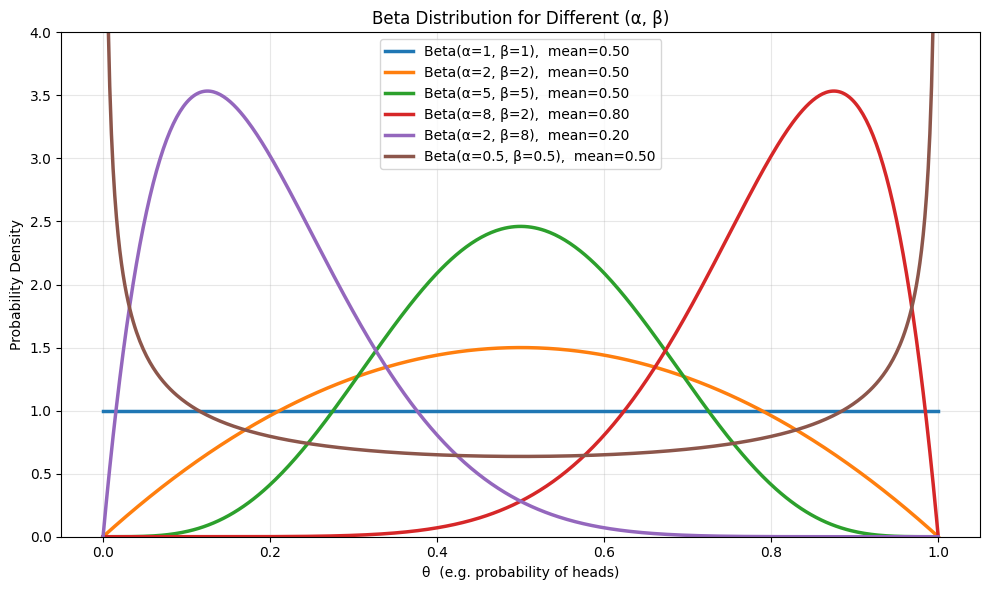

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# ==========================================
# 1. Beta 分布长什么样？(改变 alpha, beta 看形状)
# ==========================================
# 关键直觉：
#   alpha = beta = 1  -> 均匀分布 (完全无知, 任何概率都一样可能)
#   alpha = beta > 1  -> 对称的钟形 (相信 theta 接近 0.5)
#   alpha > beta      -> 向右偏 (相信 theta 偏大)
#   alpha < beta      -> 向左偏 (相信 theta 偏小)
#   alpha, beta 越大  -> 越尖锐 (信念越强, 不确定性越小)

theta = np.linspace(0, 1, 500)

# 一组有代表性的 (alpha, beta) 参数
params = [
    (1, 1),     # 均匀: 完全无知
    (2, 2),     # 弱的"偏向中间"的信念
    (5, 5),     # 强的"偏向中间"的信念
    (8, 2),     # 相信 theta 偏大
    (2, 8),     # 相信 theta 偏小
    (0.5, 0.5), # U 形: 相信 theta 接近 0 或 1 (两极分化)
]

plt.figure(figsize=(10, 6))
for a, b in params:
    plt.plot(theta, beta.pdf(theta, a, b), lw=2.5,
             label=f"Beta(α={a}, β={b}),  mean={a/(a+b):.2f}")

plt.title("Beta Distribution for Different (α, β)")
plt.xlabel("θ  (e.g. probability of heads)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 4)
plt.tight_layout()
plt.show()


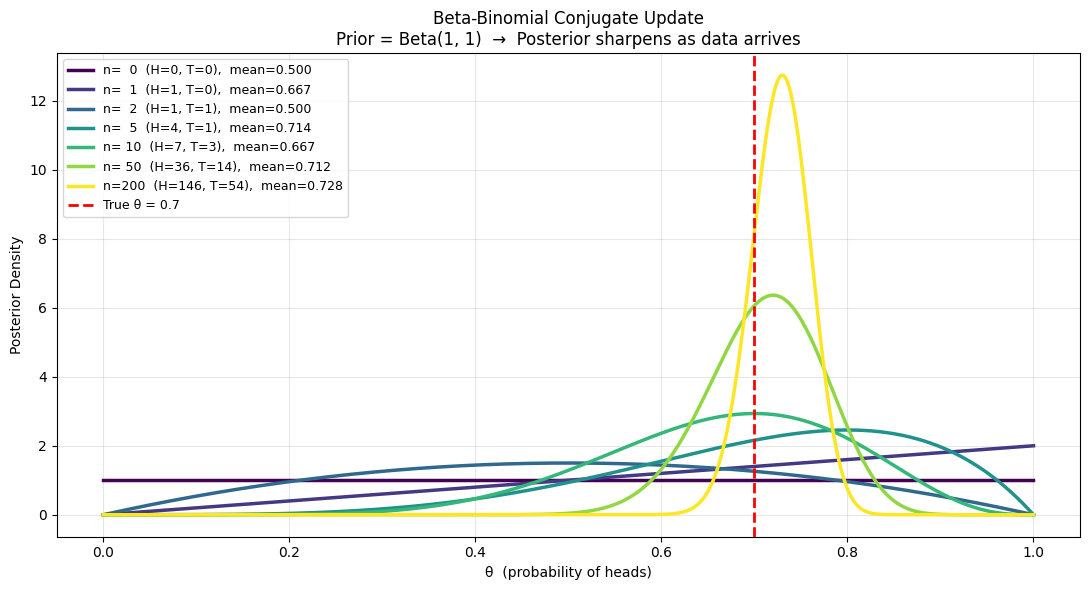

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# ==========================================
# 2. 共轭更新: 抛硬币, 看后验如何随数据收敛
# ==========================================
# 真实的硬币 (上帝视角): 正面概率 = 0.7 (一枚有偏的硬币)
TRUE_THETA = 0.7

np.random.seed(0)

def plot_conjugate_update(true_theta=0.7, prior=(1, 1),
                          snapshots=(0, 1, 2, 5, 10, 50, 200)):
    """
    prior: (alpha0, beta0) 初始先验. (1,1)=均匀=完全无知
    snapshots: 在抛了这些次数后, 各画一条后验曲线
    """
    n_total = max(snapshots)
    # 生成抛硬币结果: 1=正面(heads), 0=反面(tails)
    flips = (np.random.rand(n_total) < true_theta).astype(int)

    theta = np.linspace(0, 1, 500)
    a0, b0 = prior

    plt.figure(figsize=(11, 6))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))

    for color, n in zip(cmap, snapshots):
        h = flips[:n].sum()          # 截至目前的正面数
        t = n - h                    # 反面数
        # 共轭更新的核心: 后验 = Beta(a0 + heads, b0 + tails)
        a_post, b_post = a0 + h, b0 + t
        post_mean = a_post / (a_post + b_post)
        plt.plot(theta, beta.pdf(theta, a_post, b_post), color=color, lw=2.5,
                 label=f"n={n:>3}  (H={h}, T={t}),  mean={post_mean:.3f}")

    # 标出真实值
    plt.axvline(true_theta, color='red', ls='--', lw=2, label=f"True θ = {true_theta}")
    plt.title(f"Beta-Binomial Conjugate Update\nPrior = Beta({a0}, {b0})  →  Posterior sharpens as data arrives")
    plt.xlabel("θ  (probability of heads)")
    plt.ylabel("Posterior Density")
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 试试看：
# - prior=(1,1)   均匀先验, 完全无知
# - prior=(20,20) 强先验, 一开始就笃定 theta≈0.5, 需要更多数据才能被说服
# - prior=(2,8)   错误的先验 (以为 theta 偏小), 看数据如何最终纠正它
plot_conjugate_update(true_theta=TRUE_THETA, prior=(1, 1))


## Other Conjugate Priors

这一部分继续展示几组经典的共轭分布：

- **Poisson-Gamma**：适合计数数据，例如每分钟到达的请求数
- **Normal-Normal**：已知方差时，均值的贝叶斯更新
- **Multinomial-Dirichlet**：适合多类别离散概率，例如骰子点数或词频

它们的共同点是：**先验和后验都属于同一个分布族，更新时通常只需要做参数相加或简单变换**。

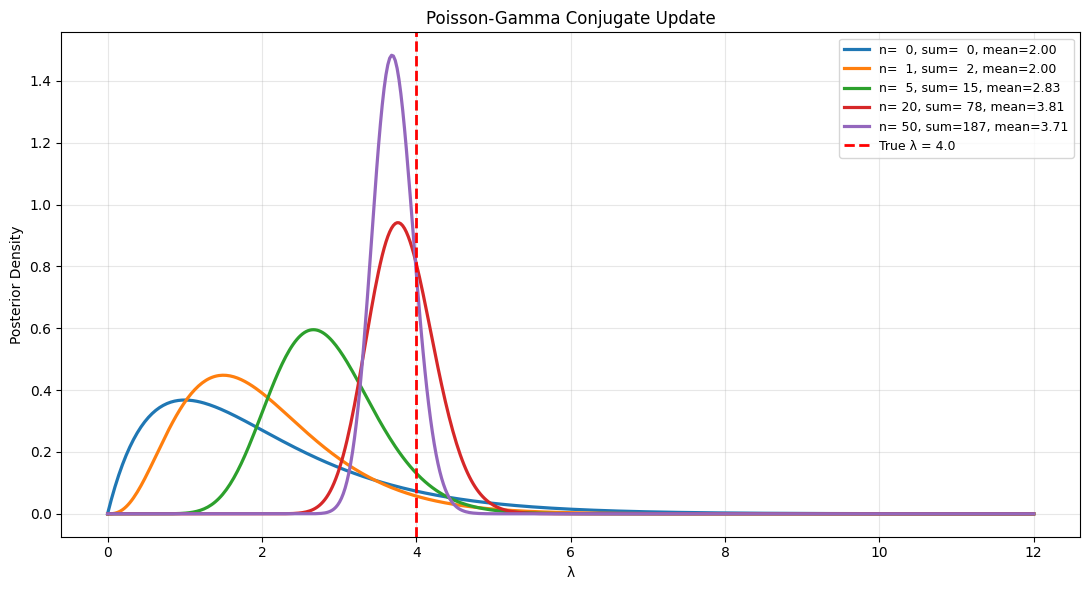

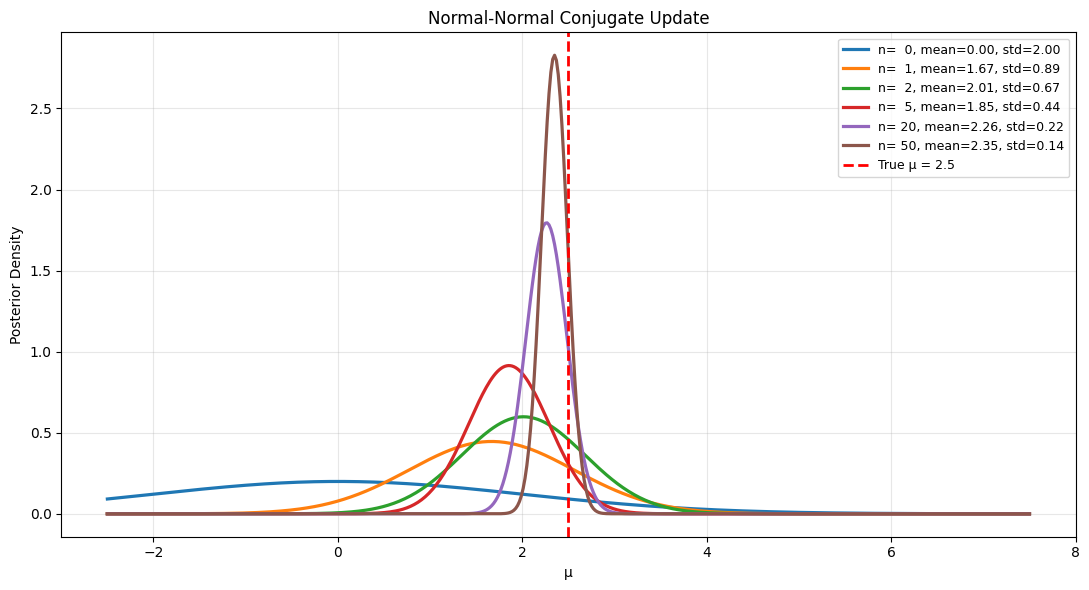

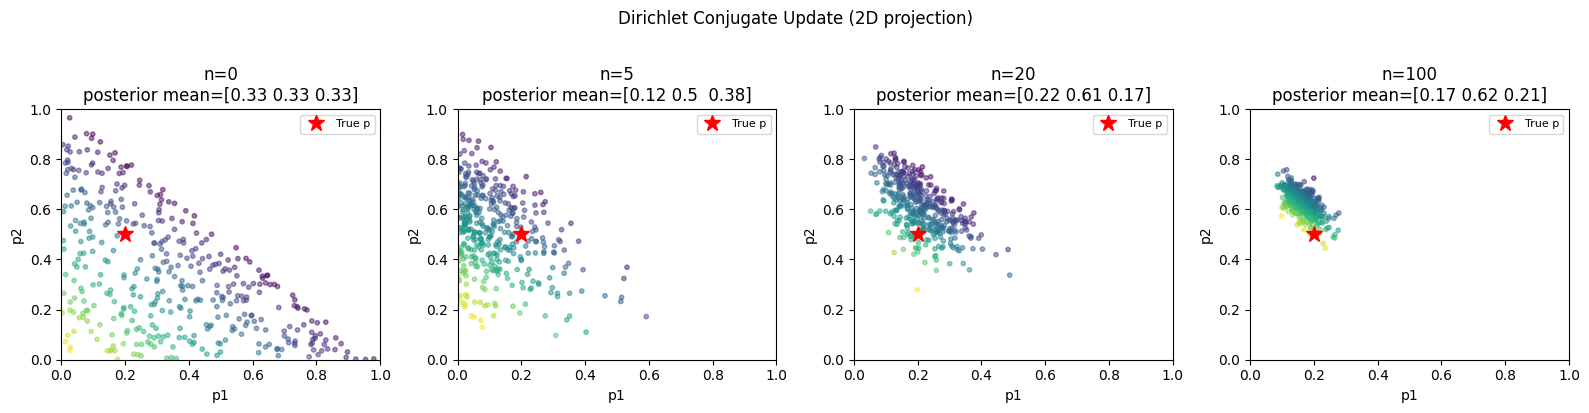

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, poisson, norm, dirichlet, multinomial

# ==========================================
# 1. Poisson-Gamma 共轭：计数数据
# ==========================================
# 观测：单位时间内的事件到达数 x ~ Poisson(lambda)
# 先验：lambda ~ Gamma(alpha, beta)
# 后验：lambda | data ~ Gamma(alpha + sum(x), beta + n)

def plot_poisson_gamma_conjugate(true_lambda=4.0, prior=(2.0, 1.0),
                                 snapshots=(0, 1, 5, 20, 50)):
    np.random.seed(1)
    alpha0, beta0 = prior
    n_total = max(snapshots)
    counts = poisson.rvs(true_lambda, size=n_total)

    lam = np.linspace(0, 12, 500)
    plt.figure(figsize=(11, 6))

    for n in snapshots:
        x_sum = counts[:n].sum()
        alpha_post = alpha0 + x_sum
        beta_post = beta0 + n
        post_mean = alpha_post / beta_post

        plt.plot(lam, gamma.pdf(lam, a=alpha_post, scale=1 / beta_post), lw=2.3,
                 label=f"n={n:>3}, sum={x_sum:>3}, mean={post_mean:.2f}")

    plt.axvline(true_lambda, color='red', ls='--', lw=2, label=f"True λ = {true_lambda}")
    plt.title("Poisson-Gamma Conjugate Update")
    plt.xlabel("λ")
    plt.ylabel("Posterior Density")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# ==========================================
# 2. Normal-Normal 共轭：已知方差时估计均值
# ==========================================
# 观测：x_i ~ Normal(mu, sigma^2)
# 先验：mu ~ Normal(mu0, tau0^2)
# 后验：mu | data 仍然是 Normal

def plot_normal_normal_conjugate(true_mu=2.5, sigma=1.0, prior_mu=0.0, prior_std=2.0,
                                 snapshots=(0, 1, 2, 5, 20, 50)):
    np.random.seed(2)
    mu0, tau0 = prior_mu, prior_std
    n_total = max(snapshots)
    obs = np.random.normal(true_mu, sigma, size=n_total)

    mu_grid = np.linspace(true_mu - 5, true_mu + 5, 500)
    plt.figure(figsize=(11, 6))

    for n in snapshots:
        x = obs[:n]
        if n == 0:
            post_mean, post_std = mu0, tau0
        else:
            precision0 = 1.0 / (tau0 ** 2)
            precision = 1.0 / (sigma ** 2)
            post_var = 1.0 / (precision0 + n * precision)
            post_mean = post_var * (precision0 * mu0 + precision * x.sum())
            post_std = np.sqrt(post_var)

        plt.plot(mu_grid, norm.pdf(mu_grid, loc=post_mean, scale=post_std), lw=2.3,
                 label=f"n={n:>3}, mean={post_mean:.2f}, std={post_std:.2f}")

    plt.axvline(true_mu, color='red', ls='--', lw=2, label=f"True μ = {true_mu}")
    plt.title("Normal-Normal Conjugate Update")
    plt.xlabel("μ")
    plt.ylabel("Posterior Density")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# ==========================================
# 3. Multinomial-Dirichlet 共轭：多类别概率
# ==========================================
# 观测：类别计数 c ~ Multinomial(n, p)
# 先验：p ~ Dirichlet(alpha)
# 后验：p | data ~ Dirichlet(alpha + counts)

def plot_dirichlet_conjugate(true_p=np.array([0.2, 0.5, 0.3]), prior=np.array([1.0, 1.0, 1.0]),
                             snapshots=(0, 5, 20, 100)):
    np.random.seed(3)
    alpha0 = np.array(prior, dtype=float)
    n_total = max(snapshots)
    samples = np.random.choice(len(true_p), size=n_total, p=true_p)

    fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
    if len(snapshots) == 1:
        axes = [axes]

    for ax, n in zip(axes, snapshots):
        counts = np.bincount(samples[:n], minlength=len(true_p))
        alpha_post = alpha0 + counts
        post_mean = alpha_post / alpha_post.sum()

        # 画在二维 simplex 上的随机样本点，帮助理解后验形状
        pts = dirichlet.rvs(alpha_post, size=400)
        ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 2], cmap='viridis', s=10, alpha=0.5)
        ax.plot(true_p[0], true_p[1], 'r*', markersize=12, label='True p')
        ax.set_title(f"n={n}\nposterior mean={np.round(post_mean, 2)}")
        ax.set_xlabel("p1")
        ax.set_ylabel("p2")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc='upper right', fontsize=8)

    plt.suptitle("Dirichlet Conjugate Update (2D projection)", y=1.02)
    plt.tight_layout()
    plt.show()


# 运行示例
plot_poisson_gamma_conjugate(true_lambda=4.0, prior=(2.0, 1.0))
plot_normal_normal_conjugate(true_mu=2.5, sigma=1.0, prior_mu=0.0, prior_std=2.0)
plot_dirichlet_conjugate(true_p=np.array([0.2, 0.5, 0.3]), prior=np.array([1.0, 1.0, 1.0]))